In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
from jax import jit, numpy as jnp, random

from modax.training.sparsity_scheduler import mask_scheduler
from modax.training.logging import Logger
from flax.core import freeze
from modax.training.utils import create_stateful_update
from sklearn.model_selection import train_test_split

import flax.linen as nn
from typing import Sequence
from modax.feature_generators import library_backward
from modax.models.networks import MLP
from modax.layers import MaskedLeastSquares

from jax.scipy.stats import t as students_t

In [3]:
class Deepmod(nn.Module):
    features: Sequence[int]

    @nn.compact
    def __call__(self, inputs):
        prediction, dt, theta = library_backward(MLP(self.features), inputs)
        coeffs = MaskedLeastSquares()((dt, theta))

        z = self.param("likelihood_params", self.likelihood_params_init)
        return prediction, dt, theta, coeffs, z

    @staticmethod
    def likelihood_params_init(key):
        z = jnp.ones((2, 2))
        return z

In [25]:
# Custom train function which always runs until max_its

def train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn,
    val_fn,
    mask_update_fn,
    X,
    y,
    max_epochs=1e4,
    split=0.2,
    rand_seed=42,
    **loss_fn_kwargs,
):
    # Making test / train
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split, random_state=rand_seed
    )

    # Creating update functions
    update = create_stateful_update(
        loss_fn, model=model, x=X_train, y=y_train, **loss_fn_kwargs
    )

    logger = Logger()
    scheduler = mask_scheduler(delta=0.0, patience=1000)

    for epoch in jnp.arange(max_epochs):
        (optimizer, state), train_metrics, output = update(optimizer, state)
        prediction, dt, theta, coeffs, z = output

        if epoch % 1000 == 0:
            print(f"Loss step {epoch}: {train_metrics['loss']}")

        if epoch % 25 == 0:
            val_metrics = val_fn(
                optimizer,
                state,
                X_test,
                y_test,
                z
            )
            metrics = {**train_metrics, **val_metrics}
            logger.write(metrics, epoch)

            apply_sparsity, optimizer = scheduler(
                metrics["val_mse"], epoch, optimizer
            )  # we need to find the minimum neg LL of the mse

            if apply_sparsity:
                mask = mask_update_fn(theta, dt)
                state = freeze({"vars": {"MaskedLeastSquares_0": {"mask": mask}}})

    logger.close()
    return optimizer, state

In [5]:
def loss_fn_mse_bayes_full(
    params, state, model, x, y):
    
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # MSE
    p_mse = jnp.sum(students_t.logpdf((y - prediction), df=jnp.exp(-z[0,0]), scale=jnp.exp(-z[0, 1])))
    MSE = jnp.mean((y-prediction)**2)

    # Reg
    p_reg = jnp.sum(students_t.logpdf((dt - theta @ coeffs), df=jnp.exp(-z[1,0]), scale=jnp.exp(-z[1, 1])))
    reg = jnp.mean((dt - theta @ coeffs)**2)

    loss = -p_mse

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs,
        "df_mse": jnp.exp(-z[0, 0]),
        "s_mse": jnp.exp(-z[0, 1]),
        "df_reg": jnp.exp(-z[1, 0]),
        "s_reg": jnp.exp(-z[1, 1]),
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs, z))

In [6]:
def validation_metric(
    params, state, model, x, y, z
):
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # MSE
    p_mse = jnp.sum(students_t.logpdf((y - prediction), df=jnp.exp(-z[0,0]), scale=jnp.exp(-z[0, 1])))
    MSE = jnp.mean((y-prediction)**2)

    # Reg
    p_reg = jnp.sum(students_t.logpdf((dt - theta @ coeffs), df=jnp.exp(-z[0,0]), scale=jnp.exp(-z[0, 1])))
    reg = jnp.mean((dt - theta @ coeffs)**2)


    metrics = {
        "val_p_mse": p_mse,
        "val_mse": MSE,
        "val_p_reg": p_reg,
        "val_reg": reg,
    }
    return metrics

In [7]:
# %% Imports
from modax.data.burgers import burgers
from modax.linear_model.mask_estimator import ThresholdedLasso
from modax.losses.bayesian import loss_fn_pinn_bayes_typeII
from flax import optim

In [8]:
# %% Making data
key = random.PRNGKey(42)

x = jnp.linspace(-3, 4, 50)
t = jnp.linspace(0.5, 5.0, 20)
t_grid, x_grid = jnp.meshgrid(t, x, indexing="ij")
u = burgers(x_grid, t_grid, 0.1, 1.0)

X = jnp.concatenate([t_grid.reshape(-1, 1), x_grid.reshape(-1, 1)], axis=1)
y = u.reshape(-1, 1)
y += 0.05 * jnp.std(y) * random.normal(key, y.shape)

In [9]:
val_fn = jit(lambda opt, state, X, y, args: validation_metric(params=opt.target, state=state, model=model, x=X, y=y, z=args))

In [10]:
model = Deepmod([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

mask_fn = ThresholdedLasso(threshold=0.1)

In [11]:
optimizer, state = train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn_mse_bayes_full,
    val_fn,
    mask_fn,
    X,
    y,
    max_epochs=50000,
    split=0.8,
    rand_seed=42,
)

Loss step 0: 135.48590087890625
Loss step 1000: -393.56097412109375
Loss step 2000: -393.56097412109375
Loss step 3000: -676.5111083984375
Loss step 4000: -706.1400756835938
Loss step 5000: -668.5628662109375
Loss step 6000: -721.0487060546875
Loss step 7000: -692.668212890625
Loss step 8000: -725.7142333984375
Loss step 9000: -728.18994140625
Loss step 10000: -733.0966186523438
Loss step 11000: -722.8951416015625
Loss step 12000: -736.6370849609375
Loss step 13000: -716.9304809570312
Loss step 14000: -751.3172607421875
Loss step 15000: -708.0771484375
Loss step 16000: -737.6986083984375
Loss step 17000: -743.57470703125
Loss step 18000: -738.70703125
Loss step 19000: -705.7197875976562
Loss step 20000: -737.4190673828125
Loss step 21000: -715.956298828125
Loss step 22000: -758.9320068359375
Loss step 23000: -727.50146484375
Loss step 24000: -742.864501953125
Loss step 25000: -691.69677734375
Loss step 26000: -755.7046508789062
Loss step 27000: -761.447998046875
Loss step 28000: -752.6

In [12]:
variables = {"params": optimizer.target, **state}
prediction = model.apply(variables, X, mutable=list(state.keys()))[0][0].reshape(x_grid.shape)

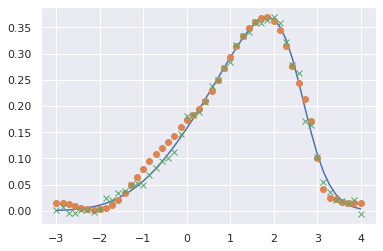

In [13]:
frame = 20
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')

In [81]:
1 / n_samples * jnp.linalg.norm(u - prediction)**2 

DeviceArray(0.00030272, dtype=float32)

In [14]:
def loss_fn_pinn_bayes_full(
    params, state, model, x, y):
    
    variables = {"params": params, **state}
    (prediction, dt, theta, coeffs, z), updated_state = model.apply(
        variables, x, mutable=list(state.keys())
    )

    # MSE
    p_mse = jnp.sum(students_t.logpdf((y - prediction), df=jnp.exp(-z[0,0]), scale=jnp.exp(-z[0, 1])))
    MSE = jnp.mean((y-prediction)**2)

    # Reg
    p_reg = jnp.sum(students_t.logpdf((dt - theta @ coeffs), df=jnp.exp(-z[1,0]), scale=jnp.exp(-z[1, 1])))
    reg = jnp.mean((dt - theta @ coeffs)**2)

    loss = -(p_mse + p_reg)

    metrics = {
        "loss": loss,
        "p_mse": p_mse,
        "mse": MSE,
        "p_reg": p_reg,
        "reg": reg,
        "coeff": coeffs,
        "df_mse": jnp.exp(-z[0, 0]),
        "s_mse": jnp.exp(-z[0, 1]),
        "df_reg": jnp.exp(-z[1, 0]),
        "s_reg": jnp.exp(-z[1, 1]),
    }
    return loss, (updated_state, metrics, (prediction, dt, theta, coeffs, z))

In [26]:
model = Deepmod([30, 30, 30, 1])
variables = model.init(key, X)

optimizer = optim.Adam(learning_rate=2e-3, beta1=0.99, beta2=0.99)
state, params = variables.pop("params")
optimizer = optimizer.create(params)

mask_fn = ThresholdedLasso(threshold=0.1)

In [27]:
optimizer, state = train_probabilistic(
    model,
    optimizer,
    state,
    loss_fn_pinn_bayes_full,
    val_fn,
    mask_fn,
    X,
    y,
    max_epochs=100000,
    split=0.8,
    rand_seed=42,
)

Loss step 0: 218.02133178710938
Loss step 1000: -790.8154296875
Loss step 2000: -1460.118896484375
Loss step 3000: -1457.239013671875
Loss step 4000: -1851.623779296875
Loss step 5000: -2123.1435546875
Loss step 6000: -2150.013671875
Loss step 7000: -1993.89697265625
Loss step 8000: -1911.20166015625
Loss step 9000: -1941.16943359375
Loss step 10000: -1956.111328125
Loss step 11000: -1959.2744140625
Loss step 12000: -1867.0838623046875
Loss step 13000: -1941.1229248046875
Loss step 14000: -1951.9891357421875
Loss step 15000: -1921.45263671875
Loss step 16000: -1940.51220703125
Loss step 17000: -1978.8714599609375
Loss step 18000: -1873.38427734375
Loss step 19000: -1881.64990234375
Loss step 20000: -1857.052978515625
Loss step 21000: -2061.912841796875
Loss step 22000: -1962.610107421875
Loss step 23000: -2014.590087890625
Loss step 24000: -1903.374267578125
Loss step 25000: -2067.642578125
Loss step 26000: -1946.3857421875
Loss step 27000: -2000.2919921875
Loss step 28000: -2027.29125

/home/gert-jan/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00018155324505642056, tolerance: 9.999999747378752e-05
  model = cd_fast.enet_coordinate_descent(
/home/gert-jan/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0001353591214865446, tolerance: 9.999999747378752e-05
  model = cd_fast.enet_coordinate_descent(


Loss step 61000: -1937.02099609375
Loss step 62000: -1794.846435546875
Loss step 63000: -1784.677001953125


/home/gert-jan/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0001191732008010149, tolerance: 9.999999747378752e-05
  model = cd_fast.enet_coordinate_descent(


Loss step 64000: -1793.74609375
Loss step 65000: -1683.485595703125
Loss step 66000: -1807.5985107421875
Loss step 67000: -1753.198486328125
Loss step 68000: -1688.474609375
Loss step 69000: -1645.458740234375
Loss step 70000: -1571.1905517578125
Loss step 71000: -1371.58447265625
Loss step 72000: -763.3764038085938
Loss step 73000: -1745.26318359375


/home/gert-jan/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:525: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.000124264057376422, tolerance: 9.86103987088427e-05
  model = cd_fast.enet_coordinate_descent_gram(


Loss step 74000: -2521.655029296875
Loss step 75000: -2978.43603515625
Loss step 76000: -3405.25439453125
Loss step 77000: -3717.1416015625
Loss step 78000: -4059.70263671875


RuntimeError: cuSolver execution failed

In [28]:
variables = {"params": optimizer.target, **state}
prediction = model.apply(variables, X, mutable=list(state.keys()))[0][0].reshape(x_grid.shape)

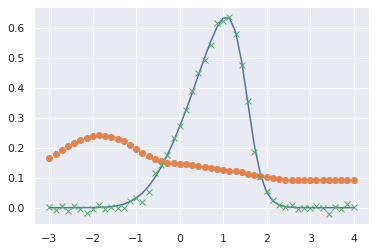

In [29]:
frame = 5
plt.plot(x, u[frame, :])
plt.plot(x, prediction[frame, :], 'o')
plt.plot(x, y.reshape(x_grid.shape)[frame, :], 'x')